# Mixture Density Networks on a 2D Synthetic Regression Problem

This notebook is a starting point for the MDN assignment. We study a one-dimensional input $x$ and a one-dimensional output $y$, so every observation is a point in the 2D plane. The conditional distribution $p(y\mid x)$ is deliberately multimodal: for the same input, the response may come from either of two smooth branches.

The experiment compares three probabilistic assumptions:
1. A deterministic neural network that predicts only a conditional mean.
2. A single-Gaussian regression network that predicts a mean and standard deviation.
3. A mixture density network (MDN) that predicts mixture weights, means, and scales.

We use a fixed train/test split, evaluate negative log likelihood (NLL) on both sets, and visualize predictive samples and density contours. The results here are intended to be extended into the report with additional mixture counts, uncertainty analysis, and a higher-dimensional real dataset.

In [14]:
import math
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.distributions import Categorical, Normal, MixtureSameFamily

# Fix random seeds so the experiment is reproducible.
SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_default_dtype(torch.float32)
# Use a GPU when available; otherwise run on the CPU.
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using {DEVICE}')

Using cpu


## 1. Generate a multimodal conditional distribution

The latent branch is sampled uniformly. Both branches are nonlinear and have different slopes, which makes a mean-only model average across modes. Small Gaussian observation noise keeps the likelihood well behaved while preserving the two modes.

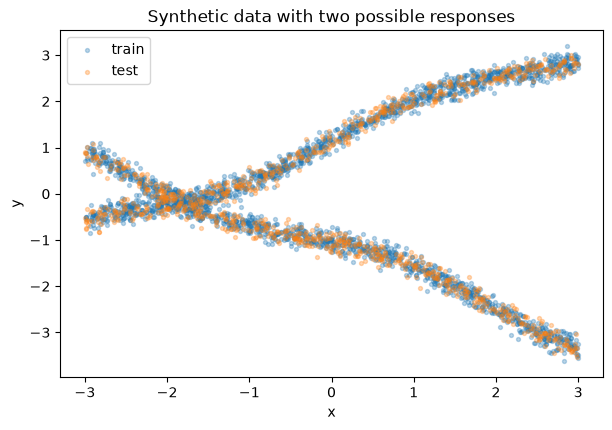

In [15]:
def make_data(n: int, seed: int):
    # Sample inputs and randomly choose one of two response branches.
    generator = torch.Generator().manual_seed(seed)
    x = 6.0 * torch.rand(n, 1, generator=generator) - 3.0
    branch = torch.randint(0, 2, (n, 1), generator=generator)
    upper = 0.65 * x + 1.15 + 0.25 * torch.sin(1.4 * x)
    lower = -0.65 * x - 1.15 + 0.25 * torch.sin(1.4 * x + 0.5)
    clean_y = torch.where(branch == 1, upper, lower)
    # Add observation noise so each branch has a small amount of spread.
    y = clean_y + 0.13 * torch.randn(n, 1, generator=generator)
    return x, y

x_train, y_train = make_data(2400, SEED)
x_test, y_test = make_data(1000, SEED + 1)

plt.figure(figsize=(7, 4.5))
plt.scatter(x_train[:, 0], y_train[:, 0], s=8, alpha=0.3, label='train')
plt.scatter(x_test[:, 0], y_test[:, 0], s=8, alpha=0.3, label='test')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Synthetic data with two possible responses')
plt.legend()
plt.show()

## 2. Models and stable likelihoods

All models share a small multilayer perceptron. The deterministic baseline is trained with mean squared error. The Gaussian models use `softplus` for positive scales and compute the log likelihood with PyTorch distributions. Computing the MDN likelihood in log space avoids underflow when several component densities are combined.

In [16]:
class Trunk(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        # Shared nonlinear feature extractor used by every regressor.
        self.net = nn.Sequential(
            nn.Linear(1, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
        )

    def forward(self, x):
        return self.net(x)


class DeterministicRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.trunk = Trunk()
        # One output gives a point prediction for y.
        self.output = nn.Linear(64, 1)

    def forward(self, x):
        return self.output(self.trunk(x))


class GaussianRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.trunk = Trunk()
        # Two outputs represent the mean and an unconstrained scale value.
        self.output = nn.Linear(64, 2)

    def forward(self, x):
        mean, raw_scale = self.output(self.trunk(x)).chunk(2, dim=-1)
        # Convert the raw value into a positive standard deviation.
        scale = torch.nn.functional.softplus(raw_scale) + 1e-3
        return mean, scale


class MDN(nn.Module):
    def __init__(self, components=2):
        super().__init__()
        self.components = components
        self.trunk = Trunk()
        # Each component needs one logit, mean, and scale parameter.
        self.output = nn.Linear(64, 3 * components)

    def forward(self, x):
        # Split the head output into one group for each Gaussian parameter.
        logits, means, raw_scales = self.output(self.trunk(x)).chunk(3, dim=-1)
        # Convert raw scales into positive standard deviations.
        scales = torch.nn.functional.softplus(raw_scales) + 1e-3
        return logits, means, scales


def gaussian_log_prob(mean, scale, y):
    # Compute the log probability of observed target values under one Gaussian.
    return Normal(mean, scale).log_prob(y).sum(dim=-1)


def mdn_log_prob(logits, means, scales, y):
    # Compute each component's log probability for the observed target values.
    component_log_probs = Normal(means, scales).log_prob(y)
    # Combine weighted component probabilities stably in log space.
    return torch.logsumexp(
        torch.log_softmax(logits, dim=-1) + component_log_probs, dim=-1
    )


def mdn_distribution(model, x):
    # Build a reusable PyTorch distribution for sampling or scoring predictions.
    logits, means, scales = model(x)
    mixture = Categorical(logits=logits)
    components = Normal(means, scales)
    return MixtureSameFamily(mixture, components)

## 3. Training utilities

The same optimizer and minibatch schedule are used for each model. The returned history lets us compare optimization behavior rather than only final test metrics.

In [ ]:
def loss_for(model, x, y, kind):
    # Select the objective that matches the model's output type.
    if kind == 'deterministic':
        return ((model(x) - y) ** 2).mean()
    if kind == 'gaussian':
        mean, scale = model(x)
        return -gaussian_log_prob(mean, scale, y).mean()
    logits, means, scales = model(x)
    return -mdn_log_prob(logits, means, scales, y).mean()


def train_model(model, kind, epochs=20, batch_size=128, learning_rate=2e-3):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    history = {'train': [], 'test': []}
    xtr, ytr = x_train.to(DEVICE), y_train.to(DEVICE)
    xte, yte = x_test.to(DEVICE), y_test.to(DEVICE)
    for epoch in range(epochs):
        # Shuffle the training examples before creating minibatches.
        permutation = torch.randperm(len(xtr), device=DEVICE)
        model.train()
        for indices in permutation.split(batch_size):
            optimizer.zero_grad()
            loss = loss_for(model, xtr[indices], ytr[indices], kind)
            loss.backward()
            optimizer.step()
        # Record full-dataset metrics after every epoch for the learning curves.
        model.eval()
        with torch.no_grad():
            history['train'].append(loss_for(model, xtr, ytr, kind).item())
            history['test'].append(loss_for(model, xte, yte, kind).item())
    return model, history


def evaluate(model, kind, x, y):
    model.eval()
    with torch.no_grad():
        # Report metrics without building a gradient graph.
        if kind == 'deterministic':
            prediction = model(x.to(DEVICE)).cpu()
            return {'mse': ((prediction - y) ** 2).mean().item()}
        if kind == 'gaussian':
            mean, scale = model(x.to(DEVICE))
            nll = -gaussian_log_prob(mean, scale, y.to(DEVICE)).mean().item()
            return {'nll': nll, 'mse_mean': ((mean.cpu() - y) ** 2).mean().item()}
        logits, means, scales = model(x.to(DEVICE))
        nll = -mdn_log_prob(logits, means, scales, y.to(DEVICE)).mean().item()
        mean_prediction = (torch.softmax(logits, -1) * means).sum(-1, keepdim=True).cpu()
        return {'nll': nll, 'mse_mean': ((mean_prediction - y) ** 2).mean().item()}

## 4. Fit the baselines and a two-component MDN

The deterministic loss is MSE, while the reported Gaussian and MDN losses are NLL. Their numerical values should therefore be compared within the probabilistic models, while the mean-prediction MSE provides a common point estimate comparison.

In [107]:
# Fit each model using the same data split and training procedure.
deterministic, deterministic_history = train_model(DeterministicRegressor(), 'deterministic')
gaussian, gaussian_history = train_model(GaussianRegressor(), 'gaussian')
mdn2, mdn2_history = train_model(MDN(components=2), 'mdn')

# Compare likelihood metrics and point-prediction errors on train and test data.
print('Deterministic train/test:', evaluate(deterministic, 'deterministic', x_train, y_train), evaluate(deterministic, 'deterministic', x_test, y_test))
print('Gaussian train/test:', evaluate(gaussian, 'gaussian', x_train, y_train), evaluate(gaussian, 'gaussian', x_test, y_test))
print('MDN-2 train/test:', evaluate(mdn2, 'mdn', x_train, y_train), evaluate(mdn2, 'mdn', x_test, y_test))

Deterministic train/test: {'mse': 2.711081027984619} {'mse': 2.6772563457489014}
Gaussian train/test: {'nll': 1.409934163093567, 'mse_mean': 2.717815637588501} {'nll': 1.415528655052185, 'mse_mean': 2.6759941577911377}
MDN-2 train/test: {'nll': 0.03679725527763367, 'mse_mean': 2.7188920974731445} {'nll': 0.05950677767395973, 'mse_mean': 2.6583409309387207}


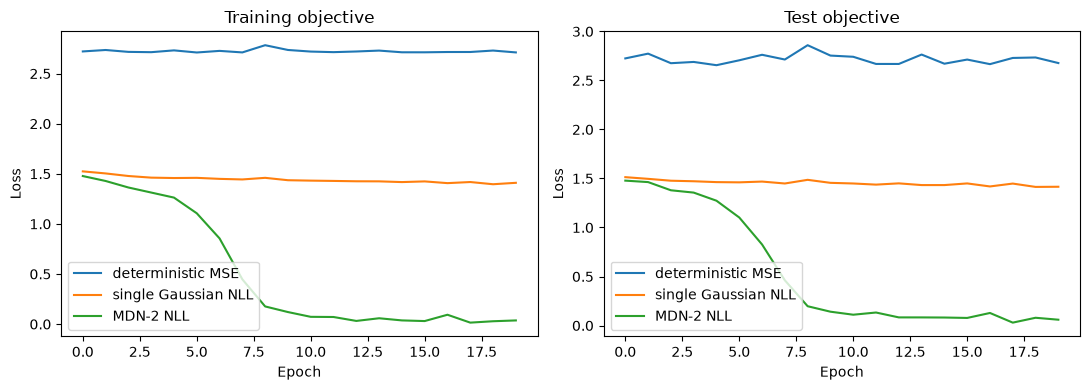

In [108]:
def plot_training_histories(histories):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    # Plot the objective on both the training and held-out test sets.
    for name, history in histories.items():
        axes[0].plot(history['train'], label=name)
        axes[1].plot(history['test'], label=name)
    axes[0].set_title('Training objective')
    axes[1].set_title('Test objective')
    for axis in axes:
        axis.set_xlabel('Epoch')
        axis.set_ylabel('Loss')
        axis.legend()
    plt.tight_layout()
    plt.show()

plot_training_histories({
    'deterministic MSE': deterministic_history,
    'single Gaussian NLL': gaussian_history,
    'MDN-2 NLL': mdn2_history,
})

## 5. Visualize predictive behavior

A useful qualitative test is whether samples from the MDN follow both branches. The deterministic prediction should pass between the branches, and the single Gaussian should represent the two modes with one broad distribution.

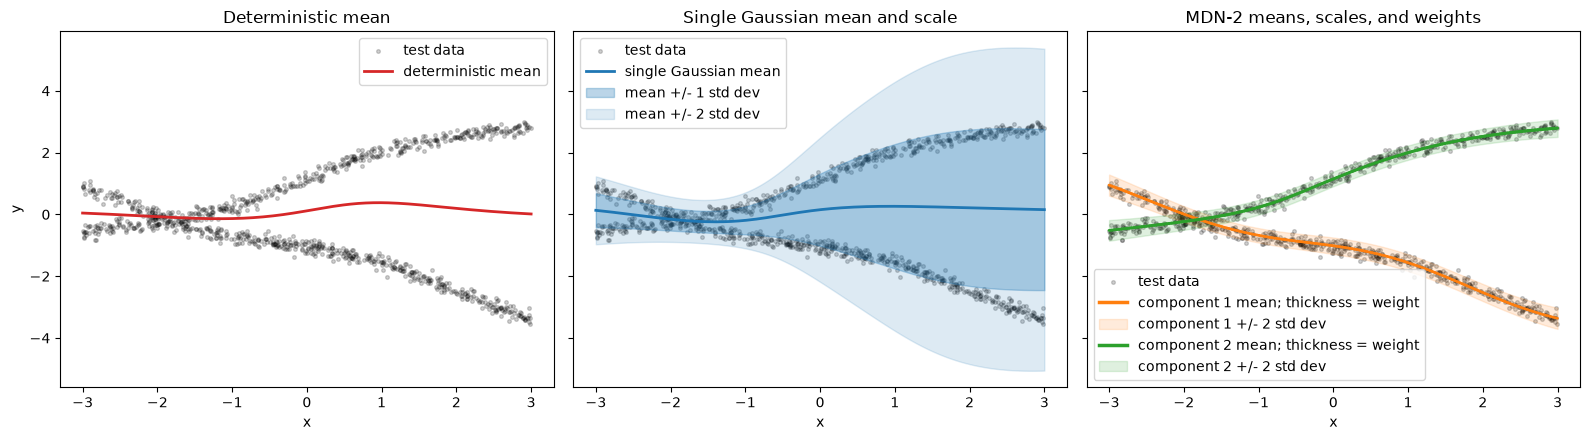

In [99]:
x_grid = torch.linspace(-3, 3, 180).reshape(-1, 1).to(DEVICE)
with torch.no_grad():
    deterministic_mean = deterministic(x_grid).cpu()
    gaussian_mean, gaussian_scale = gaussian(x_grid)
    gaussian_mean, gaussian_scale = gaussian_mean.cpu(), gaussian_scale.cpu()
    mdn_logits, mdn_means, mdn_scales = mdn2(x_grid)
    mdn_weights = torch.softmax(mdn_logits, -1).cpu()
    mdn_means, mdn_scales = mdn_means.cpu(), mdn_scales.cpu()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True, sharey=True)
for axis in axes:
    axis.scatter(x_test[:, 0], y_test[:, 0], s=7, alpha=0.18, color='black', label='test data')
axes[0].plot(x_grid.cpu(), deterministic_mean, color='tab:red', linewidth=2, label='deterministic mean')
axes[0].set_title('Deterministic mean')
axes[0].legend()

axes[1].plot(x_grid.cpu(), gaussian_mean, color='tab:blue', linewidth=2, label='single Gaussian mean')
axes[1].fill_between(
    x_grid[:, 0].cpu(),
    (gaussian_mean - gaussian_scale)[:, 0], # 1 standard deviation below the mean
    (gaussian_mean + gaussian_scale)[:, 0], # 1 standard deviation above the mean
    color='tab:blue',
    alpha=0.30,
    label='mean +/- 1 std dev'
)
axes[1].fill_between(
    x_grid[:, 0].cpu(),
    (gaussian_mean - 2 * gaussian_scale)[:, 0], # 2 standard deviations below the mean
    (gaussian_mean + 2 * gaussian_scale)[:, 0], # 2 standard deviations above the mean
    color='tab:blue',
    alpha=0.15,
    label='mean +/- 2 std dev'
)
axes[1].set_title('Single Gaussian mean and scale')
axes[1].legend()

# Encode each component's mixture weight with the thickness of its mean curve.
component_colors = ['tab:orange', 'tab:green']
for component, color in enumerate(component_colors):
    x_values = x_grid[:, 0].cpu().numpy()
    mean_values = mdn_means[:, component].numpy()
    weight_values = mdn_weights[:, component].numpy()
    for start in range(len(x_values) - 1):
        axes[2].plot(
            x_values[start:start + 2],
            mean_values[start:start + 2],
            color=color,
            linewidth=4.0 * (weight_values[start] + weight_values[start + 1]) / 2,
            solid_capstyle='round',
        )
    axes[2].plot([], [], color=color, linewidth=2.5, label=f'component {component + 1} mean; thickness = weight')
    axes[2].fill_between(
        x_grid[:, 0].cpu(),
        (mdn_means[:, component] - 2 * mdn_scales[:, component]).cpu(),
        (mdn_means[:, component] + 2 * mdn_scales[:, component]).cpu(),
        color=color,
        alpha=0.15,
        label=f'component {component + 1} +/- 2 std dev'
    )

axes[2].set_title('MDN-2 means, scales, and weights')
axes[2].legend()
for axis in axes:
    axis.set_xlabel('x')
axes[0].set_ylabel('y')
plt.tight_layout()
plt.show()

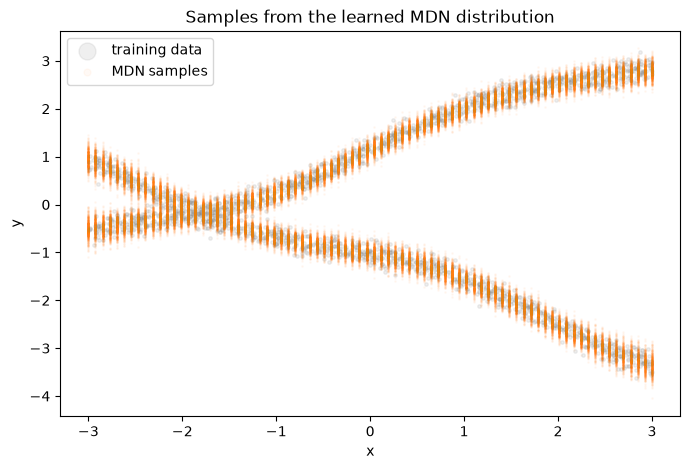

In [100]:
sample_count = 1000
x_sample = torch.linspace(-3, 3, 80).reshape(-1, 1).to(DEVICE)
with torch.no_grad():
    # Draw many samples to reveal the two learned conditional branches.
    samples = mdn_distribution(mdn2, x_sample).sample((sample_count,)).cpu()

plt.figure(figsize=(8, 5))
plt.scatter(x_train[:, 0], y_train[:, 0], s=6, alpha=0.12, color='gray', label='training data')
plt.scatter(x_sample.cpu().repeat(sample_count, 1).reshape(-1), samples.reshape(-1), s=1, alpha=0.04, color='tab:orange', label='MDN samples')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Samples from the learned MDN distribution')
plt.legend(markerscale=5)
plt.show()

## 6. Compare mixture counts

The assignment asks for a comparison across numbers of mixture components. This compact sweep is a first experiment; repeat it with several random seeds and report mean and standard deviation in the final write-up. A component count larger than the true number of modes can still improve likelihood by modeling tails, but it may also create redundant components or overfit.

In [103]:
mixture_results = []
mixture_models = {}
for components in [1, 2, 3, 5]:
    # Compare models with different numbers of Gaussian components.
    model, history = train_model(MDN(components=components), 'mdn', epochs=20)
    train_metrics = evaluate(model, 'mdn', x_train, y_train)
    test_metrics = evaluate(model, 'mdn', x_test, y_test)
    mixture_results.append((components, train_metrics['nll'], test_metrics['nll'], test_metrics['mse_mean']))
    mixture_models[components] = model

print('components | train NLL | test NLL | test mean MSE')
for result in mixture_results:
    print(f'{result[0]:10d} | {result[1]:10.4f} | {result[2]:8.4f} | {result[3]:14.4f}') 

components | train NLL | test NLL | test mean MSE
         1 |     1.3666 |   1.4000 |         2.7194
         2 |     0.0329 |   0.0498 |         2.6465
         3 |     0.0265 |   0.0680 |         2.6535
         5 |     0.0139 |   0.0543 |         2.7396


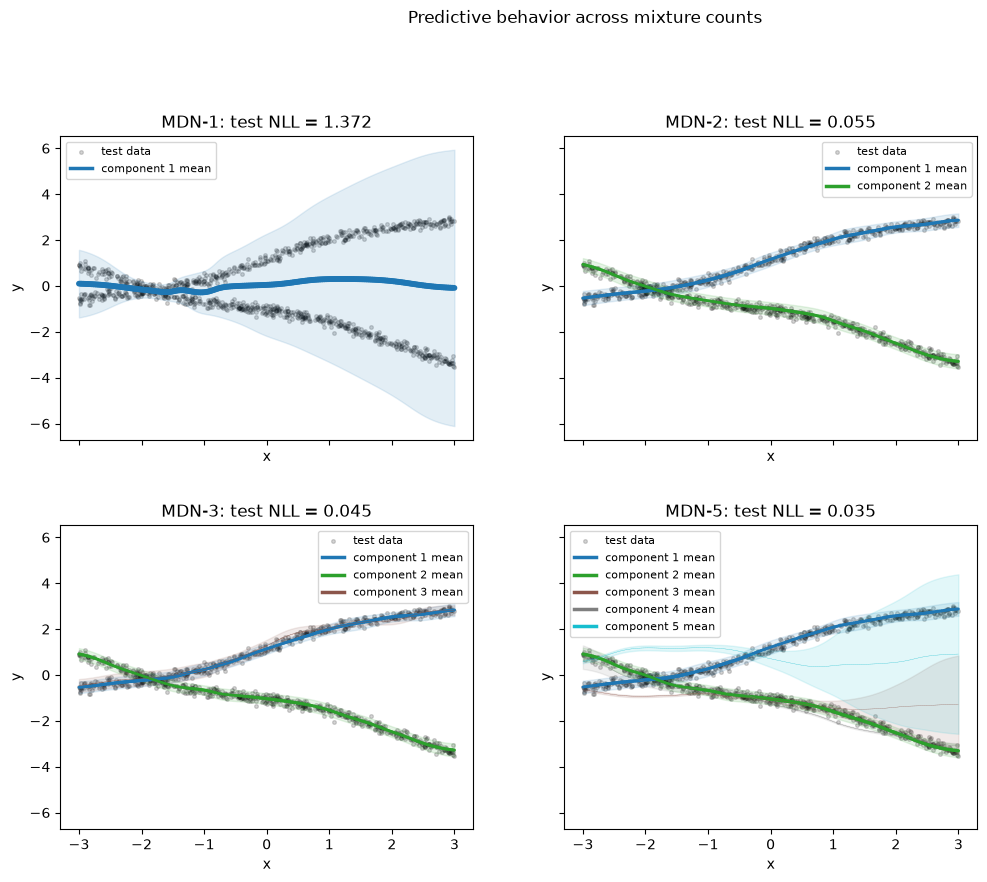

In [102]:
# Visualize how the learned predictive distribution changes with mixture count.
visualization_grid = torch.linspace(-3, 3, 180).reshape(-1, 1).to(DEVICE)
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)
axes = axes.ravel()
component_colors = plt.cm.tab10(np.linspace(0, 1, 5))

for axis, (components, train_nll, test_nll, test_mean_mse) in zip(axes, mixture_results):
    model = mixture_models[components]
    with torch.no_grad():
        logits, means, scales = model(visualization_grid)
        weights = torch.softmax(logits, dim=-1).cpu().numpy()
        means = means.cpu().numpy()
        scales = scales.cpu().numpy()

    axis.scatter(x_test[:, 0], y_test[:, 0], s=7, alpha=0.16, color='black', label='test data')
    x_values = visualization_grid[:, 0].cpu().numpy()
    for component in range(components):
        color = component_colors[component]
        weight_values = weights[:, component]
        mean_values = means[:, component]
        scale_values = scales[:, component]
        for start in range(len(x_values) - 1):
            axis.plot(
                x_values[start:start + 2],
                mean_values[start:start + 2],
                color=color,
                linewidth=0.2 + 4.0 * (weight_values[start] + weight_values[start + 1]) / 2,
                solid_capstyle='round',
            )
        axis.plot([], [], color=color, linewidth=2.5, label=f'component {component + 1} mean')
        axis.fill_between(
            x_values,
            mean_values - 2 * scale_values,
            mean_values + 2 * scale_values,
            color=color,
            alpha=0.12,
            # label=f'component {component + 1} +/- 2 std dev',
        )

    axis.set_title(f'MDN-{components}: test NLL = {test_nll:.3f}')
    axis.set_xlabel('x')
    axis.set_ylabel('y')
    if components > 5: # If more than 5 components, place the legend outside the plot
        axis.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
    else:
        axis.legend(fontsize=8)

fig.suptitle('Predictive behavior across mixture counts', y=1.02)
fig.subplots_adjust(right=0.78, hspace=0.28, wspace=0.22)
plt.show()

**Figure note.** Each shaded band shows the component mean plus or minus $2\sigma$, where $\sigma$ is the component's predicted standard deviation. The thickness of each component mean curve correlates with its mixture weight: thicker segments indicate a larger weight at that input value. The plotted linewidth is `0.2 + 4.0 * weight`, so the `0.2` baseline keeps low-weight components visible while the weight-dependent term controls most of the variation.

## 7. Initial observations and report prompts

Use the outputs above to begin the analysis. In the report, explain whether the deterministic model averages the two branches, whether the single Gaussian compensates with an inflated scale, and whether the MDN recovers separate modes. Compare train and test NLL to identify generalization or overfitting.

Suggested next steps:
- Repeat every model across at least three seeds and summarize uncertainty in the metrics.
- Add calibration checks, such as empirical coverage of predictive intervals.
- Replace the synthetic task with a realistic higher-dimensional dataset, for example UCI Yacht, Concrete Strength, or a time-series inverse problem.
- Compare parameter count and wall-clock training time, not only likelihood.
- Add density heatmaps over an $(x, y)$ grid for a more direct comparison of learned conditional distributions.

In [24]:
import pandas as pd

df = pd.read_excel("Concrete_Data.xls")

# Give the columns short, readable names.
df.columns = [
    "Cement",
    "Blast Furnace Slag",
    "Fly Ash",
    "Water",
    "Superplasticizer",
    "Coarse Aggregate",
    "Fine Aggregate",
    "Age",
    "Strength"
]

print(df.head())
print("\nDataset shape:", df.shape)

# 8 input features
X = torch.tensor(
    df.iloc[:, :-1].to_numpy(dtype=np.float32)
)

# 1 regression target: compressive strength in MPa
y = torch.tensor(
    df.iloc[:, -1:].to_numpy(dtype=np.float32)
)

# Reproducible 80/20 train/test split
generator = torch.Generator().manual_seed(SEED)
indices = torch.randperm(len(X), generator=generator)

train_size = int(0.8 * len(X))

train_indices = indices[:train_size]
test_indices = indices[train_size:]

x_concrete_train_raw = X[train_indices]
y_concrete_train_raw = y[train_indices]

x_concrete_test_raw = X[test_indices]
y_concrete_test_raw = y[test_indices]

# IMPORTANT:
# Compute normalization statistics from TRAINING DATA ONLY.
x_concrete_mean = x_concrete_train_raw.mean(dim=0, keepdim=True)
x_concrete_std = x_concrete_train_raw.std(dim=0, keepdim=True).clamp_min(1e-6)

y_concrete_mean = y_concrete_train_raw.mean(dim=0, keepdim=True)
y_concrete_std = y_concrete_train_raw.std(dim=0, keepdim=True).clamp_min(1e-6)

# Normalize inputs and target.
x_concrete_train = (
    x_concrete_train_raw - x_concrete_mean
) / x_concrete_std

x_concrete_test = (
    x_concrete_test_raw - x_concrete_mean
) / x_concrete_std

y_concrete_train = (
    y_concrete_train_raw - y_concrete_mean
) / y_concrete_std

y_concrete_test = (
    y_concrete_test_raw - y_concrete_mean
) / y_concrete_std

print("\nTrain:", x_concrete_train.shape, y_concrete_train.shape)
print("Test: ", x_concrete_test.shape, y_concrete_test.shape)

   Cement  Blast Furnace Slag  Fly Ash  Water  Superplasticizer  \
0   540.0                 0.0      0.0  162.0               2.5   
1   540.0                 0.0      0.0  162.0               2.5   
2   332.5               142.5      0.0  228.0               0.0   
3   332.5               142.5      0.0  228.0               0.0   
4   198.6               132.4      0.0  192.0               0.0   

   Coarse Aggregate  Fine Aggregate  Age   Strength  
0            1040.0           676.0   28  79.986111  
1            1055.0           676.0   28  61.887366  
2             932.0           594.0  270  40.269535  
3             932.0           594.0  365  41.052780  
4             978.4           825.5  360  44.296075  

Dataset shape: (1030, 9)

Train: torch.Size([824, 8]) torch.Size([824, 1])
Test:  torch.Size([206, 8]) torch.Size([206, 1])


In [25]:
# ============================================================
# CONCRETE EXPERIMENT - CELL 2
# Models and training function
# ============================================================

class ConcreteTrunk(nn.Module):
    def __init__(self, input_dim=8, hidden=64):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.Tanh(),

            nn.Linear(hidden, hidden),
            nn.Tanh(),
        )

    def forward(self, x):
        return self.net(x)


class ConcreteDeterministicRegressor(nn.Module):
    def __init__(self):
        super().__init__()

        self.trunk = ConcreteTrunk()

        # One output = one predicted strength value.
        self.output = nn.Linear(64, 1)

    def forward(self, x):
        return self.output(self.trunk(x))


class ConcreteGaussianRegressor(nn.Module):
    def __init__(self):
        super().__init__()

        self.trunk = ConcreteTrunk()

        # Mean + standard deviation parameter.
        self.output = nn.Linear(64, 2)

    def forward(self, x):

        mean, raw_scale = self.output(
            self.trunk(x)
        ).chunk(2, dim=-1)

        scale = (
            torch.nn.functional.softplus(raw_scale)
            + 1e-3
        )

        return mean, scale


class ConcreteMDN(nn.Module):
    def __init__(self, components=2):
        super().__init__()

        self.components = components

        self.trunk = ConcreteTrunk()

        # Each Gaussian component requires:
        # one logit, one mean, and one scale.
        self.output = nn.Linear(
            64,
            3 * components
        )

    def forward(self, x):

        logits, means, raw_scales = self.output(
            self.trunk(x)
        ).chunk(3, dim=-1)

        scales = (
            torch.nn.functional.softplus(raw_scales)
            + 1e-3
        )

        return logits, means, scales


def train_concrete(
    model,
    kind,
    epochs=500,
    batch_size=128,
    learning_rate=2e-3
):
    """
    Same idea as the notebook's train_model(),
    but uses the Concrete dataset instead of the
    synthetic global x_train/y_train.
    """

    model = model.to(DEVICE)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    history = {
        "epoch": [],
        "train": [],
        "test": []
    }

    xtr = x_concrete_train.to(DEVICE)
    ytr = y_concrete_train.to(DEVICE)

    xte = x_concrete_test.to(DEVICE)
    yte = y_concrete_test.to(DEVICE)

    for epoch in range(epochs):

        # Shuffle training examples.
        permutation = torch.randperm(
            len(xtr),
            device=DEVICE
        )

        model.train()

        for indices in permutation.split(batch_size):

            optimizer.zero_grad()

            # Reuse your EXISTING loss_for() function.
            loss = loss_for(
                model,
                xtr[indices],
                ytr[indices],
                kind
            )

            loss.backward()
            optimizer.step()

        # Save learning curves every 10 epochs.
        if (
            epoch == 0
            or (epoch + 1) % 10 == 0
            or epoch == epochs - 1
        ):

            model.eval()

            with torch.no_grad():

                train_loss = loss_for(
                    model,
                    xtr,
                    ytr,
                    kind
                ).item()

                test_loss = loss_for(
                    model,
                    xte,
                    yte,
                    kind
                ).item()

            history["epoch"].append(epoch + 1)
            history["train"].append(train_loss)
            history["test"].append(test_loss)

    return model, history

In [27]:
# ============================================================
# CONCRETE EXPERIMENT - CELL 3
# Train all models
# ============================================================

def reset_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# -------------------------
# Deterministic model
# -------------------------

print("Training deterministic model...")

reset_seed()

concrete_deterministic, concrete_det_history = train_concrete(
    ConcreteDeterministicRegressor(),
    "deterministic"
)


# -------------------------
# Single Gaussian
# -------------------------

print("Training single Gaussian...")

reset_seed()

concrete_gaussian, concrete_gauss_history = train_concrete(
    ConcreteGaussianRegressor(),
    "gaussian"
)


# -------------------------
# MDNs
# -------------------------

component_counts = [1, 2, 3, 5]

concrete_mdn_models = {}
concrete_mdn_histories = {}

for components in component_counts:

    print(f"Training MDN-{components}...")

    reset_seed()

    model, history = train_concrete(
        ConcreteMDN(components=components),
        "mdn"
    )

    concrete_mdn_models[components] = model
    concrete_mdn_histories[components] = history


print("\nFinished training all Concrete models.")

Training deterministic model...
Training single Gaussian...
Training MDN-1...
Training MDN-2...
Training MDN-3...
Training MDN-5...

Finished training all Concrete models.


In [28]:
# ============================================================
# CONCRETE EXPERIMENT - CELL 4
# Evaluate models and build results table
# ============================================================

def concrete_metrics(model, kind, x, y, y_raw):

    model.eval()

    with torch.no_grad():

        x_device = x.to(DEVICE)
        y_device = y.to(DEVICE)

        if kind == "deterministic":

            prediction = model(x_device)

            nll = np.nan

        elif kind == "gaussian":

            mean, scale = model(x_device)

            prediction = mean

            # NLL in normalized target space.
            normalized_nll = -gaussian_log_prob(
                mean,
                scale,
                y_device
            ).mean().item()

            # Convert likelihood back to original MPa scale.
            nll = (
                normalized_nll
                + math.log(y_concrete_std.item())
            )

        else:

            logits, means, scales = model(x_device)

            weights = torch.softmax(
                logits,
                dim=-1
            )

            # Expected value of the mixture:
            # E[y|x] = sum(pi_k * mu_k)
            prediction = (
                weights * means
            ).sum(dim=-1, keepdim=True)

            normalized_nll = -mdn_log_prob(
                logits,
                means,
                scales,
                y_device
            ).mean().item()

            nll = (
                normalized_nll
                + math.log(y_concrete_std.item())
            )

        # Convert normalized prediction back to MPa.
        prediction_mpa = (
            prediction.cpu() * y_concrete_std
            + y_concrete_mean
        )

        mse = (
            (prediction_mpa - y_raw) ** 2
        ).mean().item()

        rmse = math.sqrt(mse)

    return {
        "NLL": nll,
        "MSE (MPa^2)": mse,
        "RMSE (MPa)": rmse
    }


results = []


# -------------------------
# Deterministic
# -------------------------

for split, x, y, y_raw in [
    (
        "Train",
        x_concrete_train,
        y_concrete_train,
        y_concrete_train_raw
    ),
    (
        "Test",
        x_concrete_test,
        y_concrete_test,
        y_concrete_test_raw
    )
]:

    metrics = concrete_metrics(
        concrete_deterministic,
        "deterministic",
        x,
        y,
        y_raw
    )

    results.append({
        "Model": "Deterministic",
        "Split": split,
        **metrics
    })


# -------------------------
# Single Gaussian
# -------------------------

for split, x, y, y_raw in [
    (
        "Train",
        x_concrete_train,
        y_concrete_train,
        y_concrete_train_raw
    ),
    (
        "Test",
        x_concrete_test,
        y_concrete_test,
        y_concrete_test_raw
    )
]:

    metrics = concrete_metrics(
        concrete_gaussian,
        "gaussian",
        x,
        y,
        y_raw
    )

    results.append({
        "Model": "Gaussian",
        "Split": split,
        **metrics
    })


# -------------------------
# MDNs
# -------------------------

for components in component_counts:

    model = concrete_mdn_models[components]

    for split, x, y, y_raw in [
        (
            "Train",
            x_concrete_train,
            y_concrete_train,
            y_concrete_train_raw
        ),
        (
            "Test",
            x_concrete_test,
            y_concrete_test,
            y_concrete_test_raw
        )
    ]:

        metrics = concrete_metrics(
            model,
            "mdn",
            x,
            y,
            y_raw
        )

        results.append({
            "Model": f"MDN-{components}",
            "Split": split,
            **metrics
        })


concrete_results = pd.DataFrame(results)

display(
    concrete_results.round(3)
)

,Model,Split,NLL,MSE (MPa^2),RMSE (MPa)
0,Deterministic,Train,NaN,4.984,2.232
1,Deterministic,Test,NaN,16.561,4.069
2,Gaussian,Train,2.180,16.083,4.010
3,Gaussian,Test,3.721,21.589,4.646
4,MDN-1,Train,2.140,14.330,3.786
5,MDN-1,Test,4.052,21.059,4.589
6,MDN-2,Train,1.812,12.526,3.539
7,MDN-2,Test,4.025,19.672,4.435
8,MDN-3,Train,1.947,15.900,3.987
9,MDN-3,Test,3.767,20.523,4.530


Best MDN according to test NLL: MDN-3


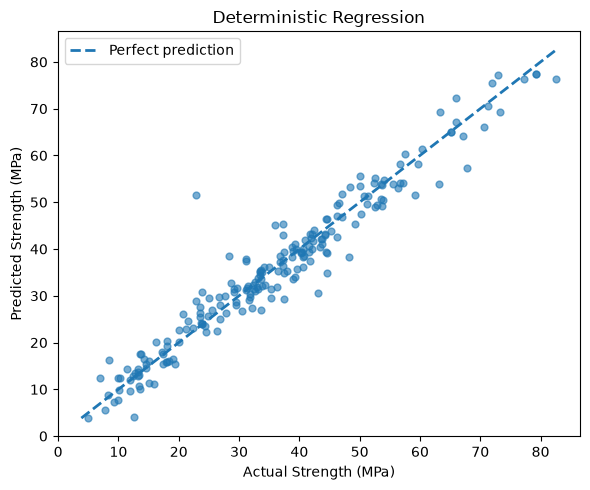

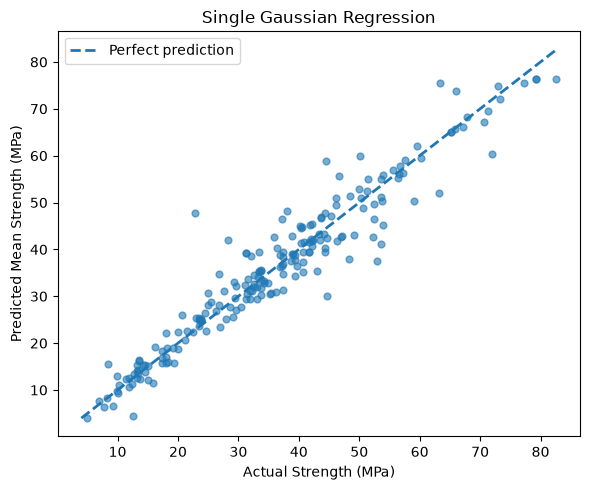

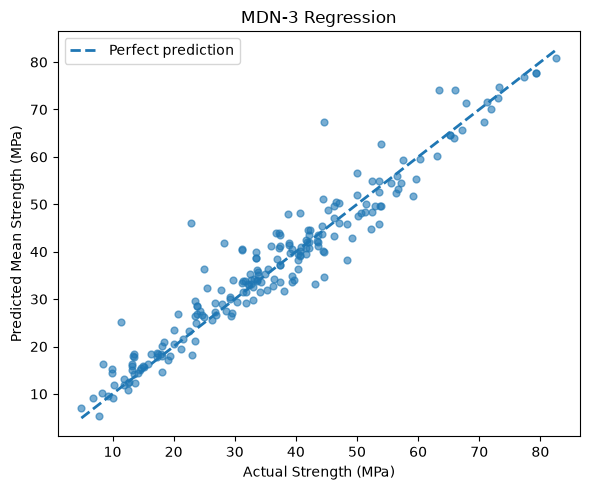

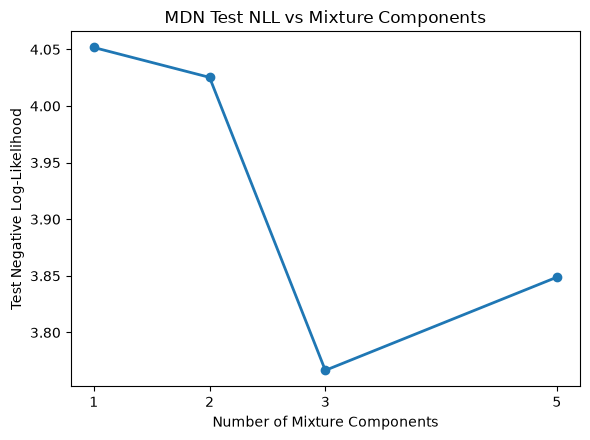

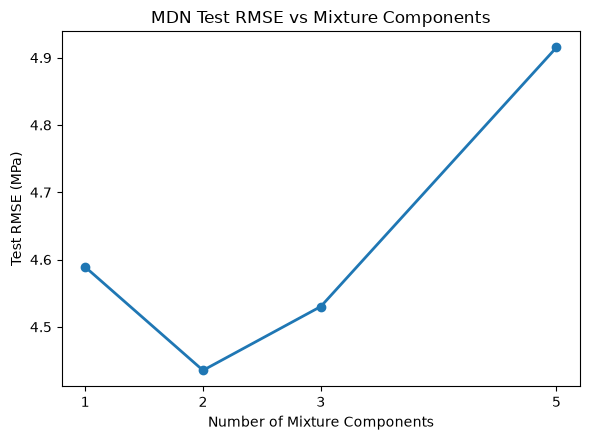

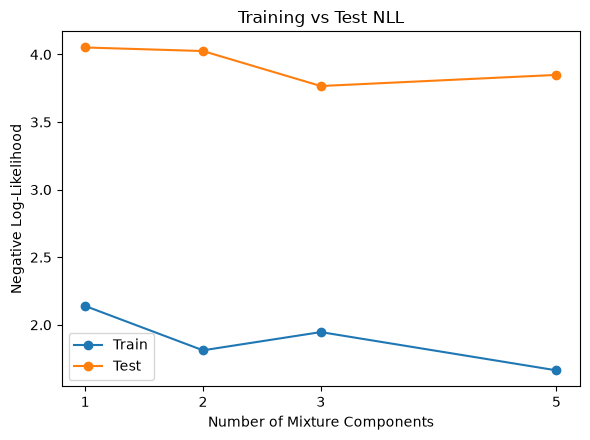

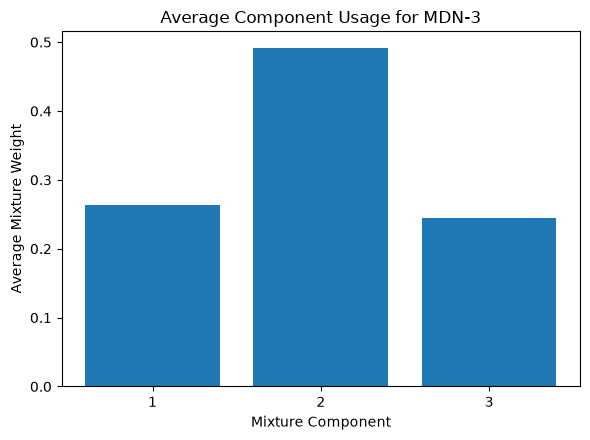


Average component weights:
Component 1: 0.264
Component 2: 0.491
Component 3: 0.245


In [29]:
# ============================================================
# CONCRETE EXPERIMENT - CELL 5
# Report plots
# ============================================================

# ------------------------------------------------------------
# Helper: get predicted mean in MPa
# ------------------------------------------------------------

def concrete_predict_mpa(model, kind, x):

    model.eval()

    with torch.no_grad():

        x = x.to(DEVICE)

        if kind == "deterministic":

            prediction = model(x)

        elif kind == "gaussian":

            prediction, _ = model(x)

        else:

            logits, means, scales = model(x)

            weights = torch.softmax(
                logits,
                dim=-1
            )

            prediction = (
                weights * means
            ).sum(dim=-1, keepdim=True)

    # Undo target normalization.
    return (
        prediction.cpu() * y_concrete_std
        + y_concrete_mean
    )


# ------------------------------------------------------------
# Find MDN with lowest TEST NLL
# ------------------------------------------------------------

test_mdn_results = concrete_results[
    (concrete_results["Split"] == "Test")
    &
    (concrete_results["Model"].str.startswith("MDN"))
].copy()

best_row = test_mdn_results.loc[
    test_mdn_results["NLL"].idxmin()
]

best_components = int(
    best_row["Model"].split("-")[1]
)

best_mdn = concrete_mdn_models[
    best_components
]

print(
    f"Best MDN according to test NLL: "
    f"MDN-{best_components}"
)


# ============================================================
# GRAPH 1
# Deterministic: predicted vs actual
# ============================================================

true_strength = y_concrete_test_raw[:, 0]

det_prediction = concrete_predict_mpa(
    concrete_deterministic,
    "deterministic",
    x_concrete_test
)[:, 0]

minimum = min(
    true_strength.min().item(),
    det_prediction.min().item()
)

maximum = max(
    true_strength.max().item(),
    det_prediction.max().item()
)

plt.figure(figsize=(6, 5))

plt.scatter(
    true_strength,
    det_prediction,
    s=24,
    alpha=0.6
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    "--",
    linewidth=2,
    label="Perfect prediction"
)

plt.xlabel("Actual Strength (MPa)")
plt.ylabel("Predicted Strength (MPa)")
plt.title("Deterministic Regression")

plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 2
# Single Gaussian: predicted vs actual
# ============================================================

gaussian_prediction = concrete_predict_mpa(
    concrete_gaussian,
    "gaussian",
    x_concrete_test
)[:, 0]

minimum = min(
    true_strength.min().item(),
    gaussian_prediction.min().item()
)

maximum = max(
    true_strength.max().item(),
    gaussian_prediction.max().item()
)

plt.figure(figsize=(6, 5))

plt.scatter(
    true_strength,
    gaussian_prediction,
    s=24,
    alpha=0.6
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    "--",
    linewidth=2,
    label="Perfect prediction"
)

plt.xlabel("Actual Strength (MPa)")
plt.ylabel("Predicted Mean Strength (MPa)")
plt.title("Single Gaussian Regression")

plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 3
# Best MDN: predicted vs actual
# ============================================================

mdn_prediction = concrete_predict_mpa(
    best_mdn,
    "mdn",
    x_concrete_test
)[:, 0]

minimum = min(
    true_strength.min().item(),
    mdn_prediction.min().item()
)

maximum = max(
    true_strength.max().item(),
    mdn_prediction.max().item()
)

plt.figure(figsize=(6, 5))

plt.scatter(
    true_strength,
    mdn_prediction,
    s=24,
    alpha=0.6
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    "--",
    linewidth=2,
    label="Perfect prediction"
)

plt.xlabel("Actual Strength (MPa)")
plt.ylabel("Predicted Mean Strength (MPa)")

plt.title(
    f"MDN-{best_components} Regression"
)

plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 4
# Test NLL vs number of mixture components
# ============================================================

test_mdn_results["Components"] = (
    test_mdn_results["Model"]
    .str.split("-")
    .str[1]
    .astype(int)
)

test_mdn_results = test_mdn_results.sort_values(
    "Components"
)

plt.figure(figsize=(6, 4.5))

plt.plot(
    test_mdn_results["Components"],
    test_mdn_results["NLL"],
    marker="o",
    linewidth=2
)

plt.xticks(component_counts)

plt.xlabel("Number of Mixture Components")
plt.ylabel("Test Negative Log-Likelihood")

plt.title(
    "MDN Test NLL vs Mixture Components"
)

plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 5
# Test RMSE vs number of mixture components
# ============================================================

plt.figure(figsize=(6, 4.5))

plt.plot(
    test_mdn_results["Components"],
    test_mdn_results["RMSE (MPa)"],
    marker="o",
    linewidth=2
)

plt.xticks(component_counts)

plt.xlabel("Number of Mixture Components")
plt.ylabel("Test RMSE (MPa)")

plt.title(
    "MDN Test RMSE vs Mixture Components"
)

plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 6
# Train vs test NLL for each mixture count
# ============================================================

train_mdn_results = concrete_results[
    (concrete_results["Split"] == "Train")
    &
    (concrete_results["Model"].str.startswith("MDN"))
].copy()

train_mdn_results["Components"] = (
    train_mdn_results["Model"]
    .str.split("-")
    .str[1]
    .astype(int)
)

train_mdn_results = train_mdn_results.sort_values(
    "Components"
)

plt.figure(figsize=(6, 4.5))

plt.plot(
    train_mdn_results["Components"],
    train_mdn_results["NLL"],
    marker="o",
    label="Train"
)

plt.plot(
    test_mdn_results["Components"],
    test_mdn_results["NLL"],
    marker="o",
    label="Test"
)

plt.xticks(component_counts)

plt.xlabel("Number of Mixture Components")
plt.ylabel("Negative Log-Likelihood")

plt.title(
    "Training vs Test NLL"
)

plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 7
# Average component weights for the best MDN
# ============================================================

best_mdn.eval()

with torch.no_grad():

    logits, means, scales = best_mdn(
        x_concrete_test.to(DEVICE)
    )

    weights = torch.softmax(
        logits,
        dim=-1
    ).cpu()

average_weights = weights.mean(dim=0)

plt.figure(figsize=(6, 4.5))

plt.bar(
    np.arange(1, best_components + 1),
    average_weights.numpy()
)

plt.xticks(
    np.arange(1, best_components + 1)
)

plt.xlabel("Mixture Component")
plt.ylabel("Average Mixture Weight")

plt.title(
    f"Average Component Usage for MDN-{best_components}"
)

plt.tight_layout()
plt.show()


print("\nAverage component weights:")

for component, weight in enumerate(
    average_weights,
    start=1
):

    print(
        f"Component {component}: "
        f"{weight.item():.3f}"
    )